#**CHAPTER 4.RECURRENT NEURAL NETWORKS**
---

##REFERENCE

https://chatgpt.com/share/69a62b20-d8c4-8012-8d68-35202b488bbf

##0.CONTEXT

*Introduction*

This notebook implements a small, character-level recurrent neural network (RNN) trained to perform next-character prediction on a fully synthetic “Sherlock-like” corpus. The goal is not to produce beautiful literature. The goal is to expose, in a controlled and reproducible setting, the mechanical idea that differentiates sequence models from the feedforward and spatial models that come earlier in ML & AI 101: an RNN processes an input one step at a time and carries forward a hidden state that acts as a compact summary of what it has seen so far. That hidden state is a learned memory, and it creates a new kind of computation: the model’s prediction at time step *t* depends not only on the current symbol but also on the internal state produced by earlier symbols. This is the minimal form of “temporal memory” in neural modeling.

The earlier chapters establish two foundations. First, KNN grounds learning as geometry: predictions come from distances in input space. Second, dense networks show how a parametric model can learn nonlinear decision boundaries via gradient descent. Third, convolutional networks introduce a spatial inductive bias: locality and weight sharing exploit the fact that nearby pixels belong together. Chapter 4 shifts the structural assumption again. Here, the data are not points in Euclidean space or pixels on a grid. The data are sequences. Sequences have order, and order creates dependencies that are not visible if you treat each element independently. A model that ignores order can only learn a bag-of-characters frequency table. It can learn that spaces are common, vowels are frequent, and punctuation patterns exist, but it cannot learn that after “Holmes” it is plausible to see a space, then a verb, then an object, then a place, because those are patterns of conditional dependency across time. The RNN is the simplest neural mechanism that can represent those dependencies.

The notebook is built to highlight the distinction between training and inference in the sequential setting. During training, the RNN is shown many short windows of text and is asked to predict the next character at every position in the window. This is supervised learning with a very dense signal: every character position produces a labeled target (the next character). Training uses teacher forcing: the model is always given the true previous characters as input when predicting the next one. This makes optimization easier, but it also creates a conceptual point that the notebook will return to repeatedly: the model’s training mode and its inference mode can diverge. At inference time, if we generate text, the model’s own predicted character becomes the next input. Any error can feed back into the context, shifting the hidden state and causing compounding drift. Watching that drift is one of the most concrete ways to understand why sequence modeling is difficult and why later chapters introduce stronger memory mechanisms.

A key mechanics-first objective in this lab is to show what “memory” means in an RNN without any mysticism. Memory is not a separate storage device; it is the evolving hidden state vector. This hidden state is updated by a deterministic computation at each step: take the embedding of the current character, combine it with the previous hidden state through learned weights, apply a nonlinearity, and produce a new hidden state. That state is then mapped to logits over the vocabulary to predict the next character. The hidden state is therefore both a representation (it encodes the past) and a computational pathway (it is the route by which gradients propagate backward through time during training). Because the same weight matrices are applied at every time step, training is equivalent to training a very deep network whose depth equals the sequence length, with weight sharing across layers. That “unrolled depth” is what produces the classic optimization issue for vanilla RNNs: gradients can vanish or explode as they traverse many repeated transformations. This notebook makes that issue visible by tracking gradient norms and by explicitly computing gradients with respect to hidden states across time.

All data in this notebook are synthetic and generated inside the notebook. That is important for two reasons. First, it ensures reproducibility: the corpus, vocabulary, and train/test split are deterministic given fixed seeds. Second, it makes the “structure” of the learning problem transparent: the corpus is generated from templates with controlled variability, so the model is learning a mixture of local character statistics (letters, punctuation, spaces) and longer-range regularities induced by repeated phrasing patterns. Because it is synthetic, we can also modify the regime in a targeted way and observe how performance changes, which is exactly what the stress test cell is designed to do.

Visualization is used throughout the notebook for mechanical clarity. Unlike CNN chapters where visualization focuses on feature maps, an RNN chapter benefits from two kinds of plots. The first is standard training instrumentation: a loss curve over epochs and a gradient norm curve that indicates whether the parameter updates are receiving stable signal. The second is interpretability oriented: plots of hidden-state norms and of gradient norms with respect to hidden states as a function of time step. These plots do not “explain meaning” in a semantic sense, but they do explain a fundamental dynamic: where the model’s internal activity is concentrated, and where learning signal is strong or weak across the sequence. When students first encounter RNNs, the vanishing gradient problem can feel like an abstract warning. Here it becomes an observable pattern tied directly to computed derivatives.

The core learning outcomes for this chapter are therefore concrete. After running the notebook end-to-end, a student should be able to describe the RNN’s forward pass as a repeated update of a hidden state driven by the current input, and they should be able to explain training as backpropagation through this unrolled computation graph. They should understand why sequence length changes difficulty: longer sequences require longer credit assignment paths and more repeated transformations, which increases optimization friction. They should see, in real metrics, how a small RNN can learn stable next-character prediction on structured synthetic text, and they should see why it has ceilings. Those ceilings motivate the next chapter’s model family, LSTMs, which introduce gating to control information flow and stabilize memory over long horizons.

Finally, the notebook is deliberately small. The network is not deep. The vocabulary is character-level rather than word-level. The objective is not language modeling excellence; it is architectural transparency. With a small model, we can keep parameter counts interpretable, training fast, and the gap between code and concept narrow. The student can trace the entire pipeline: generating the corpus, encoding characters, building fixed-length sequences, defining an embedding + RNN + linear head, training with cross-entropy loss, evaluating with accuracy and perplexity, generating text via greedy decoding, stressing the model by changing sequence length, and visualizing how internal state and gradients behave over time. That is exactly the kind of mechanics-first understanding that Chapter 4 is supposed to deliver before the course moves to gated recurrent units and then to Transformers, where sequence modeling becomes both more powerful and more complex.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Imports, Determinism, Device Selection, and Shared Plot/Train Utilities**

Cell 1 establishes the shared infrastructure that every notebook in this series relies on. The purpose is to make later cells maximally “about the model” rather than about repeated boilerplate. The cell begins by importing only the allowed libraries: Python standard modules, NumPy, Matplotlib, and PyTorch. Nothing high-level is used for training; instead, the notebook defines small helper functions that make training and evaluation explicit and inspectable.

Determinism is enforced immediately. The cell sets `random.seed(0)`, `np.random.seed(0)`, `torch.manual_seed(0)`, and `torch.cuda.manual_seed_all(0)`. This matters in a sequence model chapter because randomness enters in multiple places: synthetic corpus generation, dataset shuffling, and parameter initialization. Without fixed seeds, two runs can yield different loss curves and different generated samples, which makes mechanical interpretation harder. With determinism, any differences you see later are attributable to controlled changes (for example, the stress test), not hidden randomness.

Next, device selection is handled by `get_device()`. This function returns CUDA if available, otherwise CPU. The important point for students is that the code is written so the same tensors and models are placed on the same device consistently, which prevents the most common beginner error: mixing CPU and GPU tensors. The cell stores the choice in `DEVICE` so all later cells can use it.

A unified plotting style is set with `plt.style.use("seaborn-v0_8-darkgrid")`. Although the notebook cannot import seaborn itself, Matplotlib can use this style preset. The goal is visual consistency: comparable plots across cells and across chapters.

The cell then defines the required plotting utilities. Some are not central to Chapter 4 (such as decision boundary plots), but they are included because the book’s infrastructure contract requires them and because later chapters reuse them. For Chapter 4, the most relevant are `plot_loss_curve`, which makes training dynamics visible, and `plot_attention`, which is a placeholder for later Transformer chapters. The key requirement is that each plotting utility explicitly creates a figure, labels axes, includes a title, and calls `plt.show()`. This forces the notebook to be “observable” rather than silently producing arrays.

Finally, Cell 1 defines the PyTorch helpers `train_loop`, `evaluate`, and `predict`. In this chapter, the main training loop is implemented explicitly in Cell 5 (to expose gradient norms and minibatching), but the shared helpers remain useful for consistency and for quick checks. The `evaluate` helper uses `torch.no_grad()` to ensure evaluation does not build graphs or waste memory. It computes cross-entropy loss in a stable way by reshaping logits and targets into `(B*T, V)` and `(B*T,)`, avoiding silent broadcasting. It also computes token-level accuracy, which is a straightforward metric for next-character prediction.

The main mechanical takeaway from Cell 1 is that “reproducible experimentation” requires discipline before the model even exists. By fixing seeds, unifying device placement, standardizing plots, and providing explicit training/evaluation utilities, the notebook sets the stage for later cells to focus purely on sequence modeling mechanics: how data are encoded, how an RNN processes time, and how gradients behave when learning depends on memory across steps.

In [1]:
# ===============================
# CELL 1
# ===============================
import os
import json
import math
import time
import random
from typing import Tuple, Dict, List, Optional

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Determinism
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()

plt.style.use("seaborn-v0_8-darkgrid")

# -------------------------------
# Shared plotting utilities (mandatory signatures)
# -------------------------------
def plot_loss_curve(losses, title="Loss Curve"):
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(losses)), losses)
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    plt.show()

def plot_2d_data(X, y, title="2D Data"):
    X = np.asarray(X)
    y = np.asarray(y)
    plt.figure(figsize=(6, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, s=15)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()

def plot_decision_boundary(model, X, y, title="Decision Boundary", grid_steps=200):
    # Generic helper; only meaningful for 2D classifiers
    X = np.asarray(X)
    y = np.asarray(y)

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xs = np.linspace(x_min, x_max, grid_steps)
    ys = np.linspace(y_min, y_max, grid_steps)
    xx, yy = np.meshgrid(xs, ys)
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)

    model.eval()
    with torch.no_grad():
        inp = torch.from_numpy(grid).to(DEVICE)
        logits = model(inp)
        if logits.ndim == 2 and logits.shape[1] > 1:
            pred = torch.argmax(logits, dim=1).cpu().numpy()
        else:
            pred = (torch.sigmoid(logits).cpu().numpy().ravel() > 0.5).astype(np.int64)

    zz = pred.reshape(xx.shape)
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, zz, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=15)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()

def show_image(img, title="Image"):
    img = np.asarray(img)
    plt.figure(figsize=(4, 4))
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

def show_image_grid(images, labels=None, title="Image Grid", ncols=8):
    images = np.asarray(images)
    n = images.shape[0]
    ncols = max(1, int(ncols))
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=(ncols * 1.5, nrows * 1.5))
    for i in range(n):
        ax = plt.subplot(nrows, ncols, i + 1)
        img = images[i]
        if img.ndim == 2:
            ax.imshow(img, cmap="gray")
        else:
            ax.imshow(img)
        ax.axis("off")
        if labels is not None:
            ax.set_title(str(labels[i]), fontsize=8)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_histograms(real, fake, title="Histograms"):
    real = np.asarray(real).ravel()
    fake = np.asarray(fake).ravel()
    plt.figure(figsize=(8, 4))
    plt.hist(real, bins=40, alpha=0.6, label="Real")
    plt.hist(fake, bins=40, alpha=0.6, label="Fake")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_attention(matrix, title="Attention Matrix"):
    matrix = np.asarray(matrix)
    plt.figure(figsize=(6, 5))
    plt.imshow(matrix, aspect="auto")
    plt.colorbar()
    plt.xlabel("Key / Source Position")
    plt.ylabel("Query / Target Position")
    plt.title(title)
    plt.show()

def plot_graph(G, node_values=None, title="Graph"):
    # Lightweight placeholder (networkx optional); if not available, prints info.
    try:
        import networkx as nx
        plt.figure(figsize=(6, 6))
        pos = nx.spring_layout(G, seed=0)
        if node_values is None:
            nx.draw(G, pos, with_labels=True, node_size=500)
        else:
            vals = np.asarray([node_values.get(n, 0.0) for n in G.nodes()], dtype=np.float32)
            nx.draw(G, pos, with_labels=True, node_size=500, node_color=vals, cmap="viridis")
            plt.colorbar(plt.cm.ScalarMappable(cmap="viridis"))
        plt.title(title)
        plt.show()
    except Exception as e:
        print("plot_graph fallback (networkx not available or error):", str(e))
        print("Nodes:", getattr(G, "nodes", lambda: [])())
        print("Edges:", getattr(G, "edges", lambda: [])())

# -------------------------------
# PyTorch helpers (mandatory signatures)
# -------------------------------
def train_loop(model, optimizer, loss_fn, X, y, epochs):
    model.train()
    losses = []
    n = X.shape[0]
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad(set_to_none=True)
        logits = model(X)  # (B, T, V) for this chapter
        # reshape for CE: (B*T, V) vs (B*T,)
        B, T, V = logits.shape
        loss = loss_fn(logits.reshape(B * T, V), y.reshape(B * T))
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu().item()))
        if epoch == 1 or epoch % max(1, epochs // 10) == 0 or epoch == epochs:
            print(f"Epoch {epoch:04d}/{epochs}  Loss={losses[-1]:.4f}")
    return losses

def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        B, T, V = logits.shape
        loss = F.cross_entropy(logits.reshape(B * T, V), y.reshape(B * T))
        pred = torch.argmax(logits, dim=-1)
        acc = (pred == y).float().mean()
    return {
        "loss": float(loss.detach().cpu().item()),
        "accuracy": float(acc.detach().cpu().item())
    }

def predict(model, X):
    model.eval()
    with torch.no_grad():
        logits = model(X)
        pred = torch.argmax(logits, dim=-1)
    return pred

##2.DATE GENERATORS

###2.1.OVERVIEW

**Cell 2 — Synthetic Text Generator, Character Vocabulary, Encoding, and Sequence Dataset Builder**

Cell 2 defines the synthetic data machinery for Chapter 4. The chapter plugin specifies “synthetic Sherlock text” and gradient norms, so the data must be text-like, deterministic, and structured enough that an RNN can learn nontrivial conditional patterns. The generator `generate_sherlock_like_corpus` achieves this by combining template-based sentence structures with controlled randomness from a NumPy `RandomState`. Because it is template-driven, the corpus contains repeated motifs (subjects, verbs, objects, places, connectives), which create learnable regularities in character sequences. Because it includes randomness within a bounded set of choices, the corpus is not identical line by line; it remains varied enough to test generalization to held-out sequences.

The function is parameterized: the number of paragraphs, the random seed, and maximum sentence length can be adjusted. This is critical for later stress tests and for scaling the dataset without changing the model. The cell also enforces determinism at the generator level: it does not rely on Python’s `random`, only on NumPy with an explicit seed. This matches the specification: synthetic generators must use NumPy only and return arrays (or, in this case, return a deterministic string that will be encoded into arrays).

After generating text, the notebook must convert it into a representation usable by a neural network. The cell constructs a character-level vocabulary with `build_char_vocab`. This produces two maps: `stoi` (string-to-index) and `itos` (index-to-string). The choice of character-level modeling is deliberate. It simplifies the pipeline: no tokenizers, no word boundaries, no unknown word handling. Every character becomes a discrete symbol in a small finite alphabet. This makes the RNN’s output layer interpretable: it is literally a distribution over characters.

The conversion from text to integers is handled by `text_to_int`, returning an `int64` NumPy array of token IDs. Then `make_sequence_dataset` constructs a supervised next-character prediction dataset. For each starting position in the encoded corpus, it takes a chunk of length `seq_len + 1`. The input sequence `X` is the first `seq_len` characters, and the target sequence `y` is the next `seq_len` characters, i.e., the same chunk shifted by one. This creates a dense supervision signal: each time step in the input predicts the immediate next character. The `stride` parameter controls overlap: smaller stride means more training examples with strong correlation; larger stride reduces redundancy.

Finally, `train_test_split_np` creates an explicit train/test split by shuffling sequence indices deterministically with a fixed seed. This is important because sequences are overlapping; without shuffling, train and test could contain very similar contiguous regions, inflating apparent performance. Shuffling helps break that correlation. The cell also provides `decode_ints` to invert encoded sequences back to text. This is not a training necessity, but it is a pedagogy necessity: it lets the student verify that the dataset genuinely corresponds to readable text-like patterns.

The mechanical takeaway from Cell 2 is that sequence modeling begins with a representation choice. By building a character vocabulary and a shifted dataset, the notebook turns the problem “predict what comes next in text” into a standard supervised learning task with explicit inputs, explicit labels, and an unambiguous loss function. Everything that follows—RNN architecture, training, evaluation, inference—depends on this encoding and on the fact that time is now an axis of the data, not an afterthought.

###2.2.CODE AND IMPLEMENTATION

In [2]:
# ===============================
# CELL 2
# ===============================
def generate_sherlock_like_corpus(
    n_paragraphs: int = 60,
    seed: int = 0,
    max_sentence_len: int = 140
) -> str:
    """
    Deterministic synthetic "Sherlock-like" corpus.
    Uses templates + controlled randomness to create repeatable text with structure.
    NumPy only.
    """
    rng = np.random.RandomState(seed)

    subjects = [
        "Holmes", "Watson", "Lestrade", "the inspector", "the client",
        "the visitor", "the stranger", "the landlady", "the clerk"
    ]
    verbs = [
        "observed", "remarked", "whispered", "declared", "insisted",
        "concluded", "deduced", "recalled", "suspected"
    ]
    objects = [
        "a curious footprint", "a torn letter", "a faint perfume",
        "an ash tray", "a broken watch", "a cryptic note",
        "a muddy boot", "a strange map", "a sealed envelope"
    ]
    places = [
        "Baker Street", "the foggy alley", "the railway station",
        "the dim corridor", "the old manor", "the riverside",
        "the quiet chapel", "the crowded market", "the empty carriage"
    ]
    connectives = [
        "therefore", "however", "nevertheless", "meanwhile",
        "in short", "as a result", "for that reason"
    ]
    tones = [
        "with calm certainty", "with a sudden start", "in a low voice",
        "with careful emphasis", "as if amused", "without hesitation"
    ]

    paragraphs = []
    for _ in range(n_paragraphs):
        n_sent = int(rng.randint(3, 7))  # 3..6 sentences
        sents = []
        for _j in range(n_sent):
            s = rng.choice(subjects)
            v = rng.choice(verbs)
            o = rng.choice(objects)
            p = rng.choice(places)
            c = rng.choice(connectives)
            t = rng.choice(tones)

            # Simple structure with punctuation variety
            if rng.rand() < 0.35:
                sent = f"{s} {v} {o} at {p}, {t}."
            elif rng.rand() < 0.7:
                sent = f"At {p}, {s} {v} {o}; {c}, we listened {t}."
            else:
                sent = f"{c.capitalize()}, {s} {v} that {o} came from {p} {t}."

            # Cap sentence length deterministically by trimming
            if len(sent) > max_sentence_len:
                sent = sent[:max_sentence_len - 1] + "."
            sents.append(sent)

        para = " ".join(sents)
        paragraphs.append(para)

    corpus = "\n\n".join(paragraphs)
    return corpus

def build_char_vocab(text: str) -> Tuple[Dict[str, int], Dict[int, str]]:
    chars = sorted(list(set(text)))
    stoi = {ch: i for i, ch in enumerate(chars)}
    itos = {i: ch for ch, i in stoi.items()}
    return stoi, itos

def text_to_int(text: str, stoi: Dict[str, int]) -> np.ndarray:
    arr = np.array([stoi[ch] for ch in text], dtype=np.int64)
    return arr

def make_sequence_dataset(
    encoded: np.ndarray,
    seq_len: int = 64,
    stride: int = 1
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Next-character prediction dataset:
    X: sequences of length seq_len
    y: next characters (also length seq_len), shifted by +1
    """
    n = int(encoded.shape[0])
    max_start = n - (seq_len + 1)
    starts = np.arange(0, max_start, stride, dtype=np.int64)

    X = np.zeros((starts.shape[0], seq_len), dtype=np.int64)
    y = np.zeros((starts.shape[0], seq_len), dtype=np.int64)

    for i, s in enumerate(starts):
        chunk = encoded[s : s + seq_len + 1]
        X[i] = chunk[:-1]
        y[i] = chunk[1:]

    return X, y

def train_test_split_np(X: np.ndarray, y: np.ndarray, test_ratio: float = 0.2, seed: int = 0):
    rng = np.random.RandomState(seed)
    idx = np.arange(X.shape[0], dtype=np.int64)
    rng.shuffle(idx)
    n_test = int(np.floor(test_ratio * X.shape[0]))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

def decode_ints(ints: np.ndarray, itos: Dict[int, str]) -> str:
    return "".join([itos[int(i)] for i in ints.tolist()])

##3.DATA SET CREATION AND VISUALIZATION

###3.1.OVERVIEW

**Cell 3 — Dataset Instantiation, Visualization of Structure, and Torch Tensor Preparation**

Cell 3 executes the generators from Cell 2 to produce the actual dataset used for training and evaluation. This is where the notebook becomes concrete: the synthetic corpus is created, vocabulary size is established, and the sequence dataset is built with fixed hyperparameters. The cell defines the key constants: `VOCAB_SIZE`, `SEQ_LEN`, and `STRIDE`. These values define the learning problem’s resolution. `VOCAB_SIZE` determines the classification space for each time step. `SEQ_LEN` determines how far the model must carry memory within each training example. `STRIDE` determines how densely the corpus is sampled into training windows.

After dataset creation, the cell prints basic statistics: corpus length, vocabulary size, and the number of train/test sequences. These numbers matter because they determine both sample complexity and compute. For example, token-level classification is performed at every position, so increasing `SEQ_LEN` increases the number of predictions per batch and increases backpropagation depth through time.

The cell then visualizes character frequency. This is not merely decorative. It exposes what a “bag-of-characters” baseline would learn: which symbols are common and which are rare. In a character-level dataset, frequency is highly skewed: spaces and common letters dominate; punctuation and rare letters appear less. This skew affects learning because cross-entropy loss is averaged across positions: the model can reduce loss substantially by learning to predict frequent characters well. Seeing this frequency distribution helps students interpret why early training often learns spacing and punctuation patterns before learning more specific sequences.

The cell also prints a few decoded examples of input and target sequences. This is the most direct visualization of the supervised learning setup. Students can literally see the shift: the target sequence is the input sequence moved one character ahead. This clarifies what “next-character prediction” means at the level of arrays. It also makes clear that training is teacher-forced: at each position, the model receives the true preceding characters as context.

Finally, the cell converts NumPy arrays into PyTorch tensors and moves them to the chosen device. Token IDs are kept as `long` tensors because embeddings require integer indices. This is a subtle but important numerical point: unlike image data or real-valued vectors, discrete tokens are not normalized as float inputs. Normalization in this setting occurs implicitly through learned embeddings, which map token IDs into float vectors. By explicitly converting to `.long()` and moving to `DEVICE`, the notebook avoids silent type mismatches and device mismatches later.

The mechanical takeaway from Cell 3 is that sequence datasets have two distinct structures to observe: statistical structure (frequency distributions) and sequential structure (shifted input/target windows). The plots and printed examples make both visible. This prepares the student to understand what the RNN must learn: not only local character frequencies, but conditional dependencies across time steps within a window.

###3.2.CODE AND IMPLEMENTATION

Corpus length (chars): 33458
Vocab size: 39
Train sequences: 8905  Test sequences: 2226


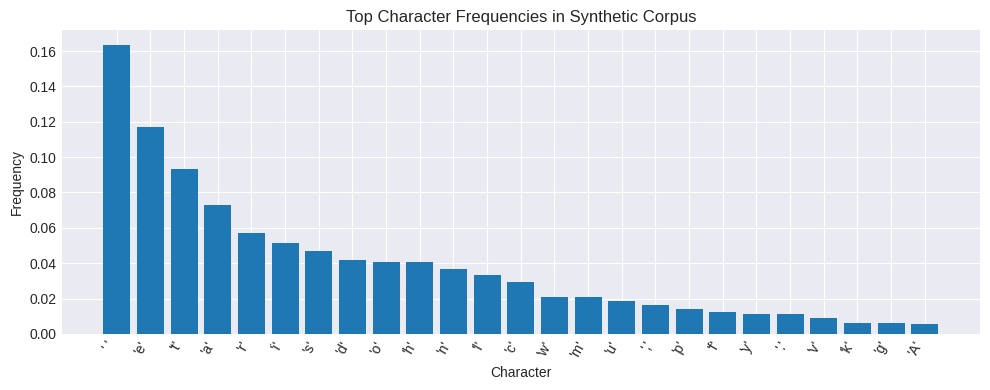


--- Example 0 ---
X: dden start. Holmes whispered a torn letter at the old manor, wit
y: den start. Holmes whispered a torn letter at the old manor, with

--- Example 1 ---
X:  a curious footprint at the dim corridor, with calm certainty.


y: a curious footprint at the dim corridor, with calm certainty.

A

--- Example 2 ---
X: r concluded a strange map; as a result, we listened with a sudde
y:  concluded a strange map; as a result, we listened with a sudden


In [3]:
# ===============================
# CELL 3
# ===============================
# Dataset creation + visualization
corpus = generate_sherlock_like_corpus(n_paragraphs=80, seed=0)
stoi, itos = build_char_vocab(corpus)
encoded = text_to_int(corpus, stoi)

VOCAB_SIZE = len(stoi)
SEQ_LEN = 64
STRIDE = 3

X_np, y_np = make_sequence_dataset(encoded, seq_len=SEQ_LEN, stride=STRIDE)
X_train_np, y_train_np, X_test_np, y_test_np = train_test_split_np(X_np, y_np, test_ratio=0.2, seed=0)

# Show sample text and basic stats
print("Corpus length (chars):", len(corpus))
print("Vocab size:", VOCAB_SIZE)
print("Train sequences:", X_train_np.shape[0], " Test sequences:", X_test_np.shape[0])

# Visualize character frequency (structure of the synthetic "language")
counts = np.bincount(encoded, minlength=VOCAB_SIZE).astype(np.float64)
freq = counts / counts.sum()

topk = 25
top_idx = np.argsort(freq)[::-1][:topk]
top_chars = [repr(itos[i]) for i in top_idx]
top_freq = freq[top_idx]

plt.figure(figsize=(10, 4))
plt.bar(np.arange(topk), top_freq)
plt.xticks(np.arange(topk), top_chars, rotation=60, ha="right")
plt.xlabel("Character")
plt.ylabel("Frequency")
plt.title("Top Character Frequencies in Synthetic Corpus")
plt.tight_layout()
plt.show()

# Visualize a few decoded input->target examples
n_show = 3
for i in range(n_show):
    x0 = X_train_np[i]
    y0 = y_train_np[i]
    print("\n--- Example", i, "---")
    print("X:", decode_ints(x0[:80], itos))
    print("y:", decode_ints(y0[:80], itos))

# Convert to torch tensors (float32 not applicable for token IDs; embeddings handle)
X_train = torch.from_numpy(X_train_np).long().to(DEVICE)
y_train = torch.from_numpy(y_train_np).long().to(DEVICE)
X_test = torch.from_numpy(X_test_np).long().to(DEVICE)
y_test = torch.from_numpy(y_test_np).long().to(DEVICE)

##4.MODEL DEFINITION


###4.1.OVERVIEW

**Cell 4 — Small Character-Level RNN Definition and Parameter Transparency**

Cell 4 defines the model. The architecture is intentionally minimal: an embedding layer maps each character token into a dense vector; a vanilla `nn.RNN` processes the sequence of embeddings and produces a sequence of hidden states; a linear layer maps each hidden state to logits over the vocabulary. This three-stage pipeline is the essence of a basic RNN language model.

The embedding layer is critical. Without it, the model would need to work directly with one-hot vectors of size `VOCAB_SIZE`, which is inefficient and forces the RNN to learn with a sparse, high-dimensional input. The embedding replaces that with a compact learned representation of characters. Importantly, embeddings are learned jointly with the RNN weights. That means “character similarity” (for example, vowels being used in similar contexts) can be represented geometrically inside the embedding space.

The RNN layer is configured with `batch_first=True`, which sets the tensor layout to `(B, T, E)` for inputs and `(B, T, H)` for outputs. This layout is more intuitive for students: batch dimension first, then time. The RNN uses `tanh` nonlinearity, the classic vanilla RNN update. Mechanically, each time step applies the same weight matrices to combine the current input embedding and the previous hidden state. This weight sharing across time is what makes RNNs special and what also creates their training difficulties: during backpropagation, gradients must pass through repeated multiplications by the same recurrent matrix.

The final linear layer produces logits of shape `(B, T, V)`. Each time step yields a distribution over the next character. This is a dense prediction task: every time step contributes to the loss.

Cell 4 also prints the model and its parameter count. This transparency is a key pedagogical point. RNNs can feel opaque if treated as black boxes. Counting parameters forces you to see where capacity lives: embeddings scale with `VOCAB_SIZE * emb_dim`; recurrent weights scale with `hidden_dim^2` (plus input-to-hidden terms); the output layer scales with `hidden_dim * VOCAB_SIZE`. This helps students reason about why character-level models can become expensive if vocabularies or hidden sizes grow.

The mechanical takeaway from Cell 4 is the mapping from a sequence of discrete tokens into a sequence of predictions. The model’s forward pass is explicit: token IDs → embeddings → recurrent hidden states → logits. Nothing about “memory” is magical; it is the hidden state vector evolving through time under learned transformations.

###4.2.CODE AND IMPLEMENTATION

In [4]:
# ===============================
# CELL 4
# ===============================
# Model definition (small pedagogical RNN)
class CharRNN(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int = 32, hidden_dim: int = 64, num_layers: int = 1):
        super().__init__()
        self.vocab_size = vocab_size
        self.emb = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            nonlinearity="tanh",
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x_tokens: torch.Tensor) -> torch.Tensor:
        # x_tokens: (B, T) int64
        x = self.emb(x_tokens)           # (B, T, E)
        h, _ = self.rnn(x)               # (B, T, H)
        logits = self.fc(h)              # (B, T, V)
        return logits

EMB_DIM = 32
HIDDEN_DIM = 64
NUM_LAYERS = 1

model = CharRNN(VOCAB_SIZE, emb_dim=EMB_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS).to(DEVICE)
print(model)

# Parameter count (for transparency)
n_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", n_params)

CharRNN(
  (emb): Embedding(39, 32)
  (rnn): RNN(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=39, bias=True)
)
Total parameters: 10055


##5.TRAINING LOOP

###5.1.OVERVIEW

**Cell 5 — Explicit Mini-Batch Training with Backpropagation Through Time and Gradient Norm Tracking**

Cell 5 performs training. Although Cell 1 includes a generic `train_loop`, this cell implements a custom loop to make two RNN-specific mechanics explicit: mini-batching for sequence windows and gradient norm tracking as a stability diagnostic. Training proceeds in epochs. For each epoch, the notebook shuffles training windows deterministically (using a seed tied to the epoch index) and iterates in batches.

For each batch, the model produces logits of shape `(B, T, V)`. The loss is cross-entropy over all time steps, computed by reshaping logits to `(B*T, V)` and targets to `(B*T,)`. This ensures the loss is computed as a standard multi-class classification problem repeated across positions. This reshape is mechanically important because it makes clear that next-character prediction is not a single label per sequence; it is a label per time step.

The optimizer is Adam, which is a common choice for sequence models because it handles scale differences across parameters reasonably well. The learning rate is modest to keep training stable. After computing the loss, the notebook calls `loss.backward()`. This triggers backpropagation through time (BPTT). In PyTorch, the unrolling is automatic: the computational graph includes the repeated RNN computations across the time axis.

Immediately after backpropagation, the cell computes a global gradient norm across all parameters. This is a single scalar diagnostic: the L2 norm of the concatenated gradient vector. Tracking this norm helps detect two pathological regimes. If norms explode, optimization becomes unstable and loss can diverge. If norms vanish toward zero, learning slows dramatically because parameter updates become tiny. In vanilla RNNs, both regimes can happen depending on initialization, sequence length, and learning rate. Here, the notebook records gradient norms epoch by epoch to provide an empirical view of training stability.

The cell stores two histories: mean training loss per epoch and mean gradient norm per epoch. It prints progress periodically. This printing is not cosmetic; it creates an observable connection between training time and learning signal.

The mechanical takeaway from Cell 5 is that RNN training is “deep” in time. Even with a small model, the effective depth is the sequence length. Gradient norms become an essential instrument because they reflect the health of the learning signal as it passes backward through repeated transformations. This sets up the interpretability cell later, which will compute gradients with respect to hidden states at each time step, making the vanishing/exploding intuition even more direct.

###5.2.CODE AND IMPLEMENTATION

In [5]:
# ===============================
# CELL 5
# ===============================
# Training loop (mini-batch BPTT style)
def batch_iter(X: torch.Tensor, y: torch.Tensor, batch_size: int = 64, seed: int = 0):
    rng = np.random.RandomState(seed)
    idx = np.arange(X.shape[0], dtype=np.int64)
    rng.shuffle(idx)
    for start in range(0, idx.shape[0], batch_size):
        batch_idx = idx[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]

def grad_global_norm(model: nn.Module) -> float:
    total = 0.0
    for p in model.parameters():
        if p.grad is None:
            continue
        g = p.grad.detach()
        total += float(torch.sum(g * g).item())
    return float(np.sqrt(total))

LR = 2e-3
EPOCHS = 12
BATCH_SIZE = 64

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()

train_losses = []
train_grad_norms = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_losses = []
    epoch_gradnorms = []
    for xb, yb in batch_iter(X_train, y_train, batch_size=BATCH_SIZE, seed=epoch):
        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        B, T, V = logits.shape
        loss = loss_fn(logits.reshape(B * T, V), yb.reshape(B * T))
        loss.backward()
        gn = grad_global_norm(model)
        optimizer.step()

        epoch_losses.append(float(loss.detach().cpu().item()))
        epoch_gradnorms.append(gn)

    mean_loss = float(np.mean(epoch_losses))
    mean_gn = float(np.mean(epoch_gradnorms))
    train_losses.append(mean_loss)
    train_grad_norms.append(mean_gn)

    if epoch == 1 or epoch % 2 == 0 or epoch == EPOCHS:
        print(f"Epoch {epoch:02d}/{EPOCHS}  TrainLoss={mean_loss:.4f}  GradNorm={mean_gn:.4f}")

Epoch 01/12  TrainLoss=2.0537  GradNorm=0.2635
Epoch 02/12  TrainLoss=0.7631  GradNorm=0.1872
Epoch 04/12  TrainLoss=0.3340  GradNorm=0.1653
Epoch 06/12  TrainLoss=0.2804  GradNorm=0.1647
Epoch 08/12  TrainLoss=0.2602  GradNorm=0.1712
Epoch 10/12  TrainLoss=0.2484  GradNorm=0.1756
Epoch 12/12  TrainLoss=0.2402  GradNorm=0.1825


##6.EVALUATION

###6.1.OVERVIEW

**Cell 6 — Evaluation Metrics, Perplexity, and Visualization of Training/Gradient Dynamics**

Cell 6 evaluates the trained model and visualizes the learning process. Evaluation is done on both a subset of the training data (to measure fit) and a subset of the test data (to measure generalization). The evaluation function uses `torch.no_grad()` so gradients are not tracked during metric computation. This ensures the evaluation is purely inference: forward pass only, no learning signal, no graph building.

Two metrics are computed: cross-entropy loss and token-level accuracy. Loss is the primary optimization objective. Accuracy is an interpretable proxy: it answers “what fraction of next characters were predicted exactly right?” In character-level modeling, accuracy can be deceptively high if the dataset has strong frequency skew; nonetheless, tracking it alongside loss is helpful.

The cell also computes perplexity as `exp(loss)`. Perplexity is a standard language modeling metric that can be interpreted as an “effective branching factor”: lower perplexity means the model is less uncertain about what comes next. The notebook uses perplexity mainly because it is easy to compute from loss and gives a different numerical scale that students may see in sequence modeling contexts.

Visualization comes next. The loss curve plot shows how training progressed across epochs. Students should observe whether loss decreases smoothly, plateaus, or oscillates. A smooth decrease suggests stable optimization; a noisy curve suggests learning rate or batch size issues; a plateau suggests limited capacity or that the model has extracted the easiest patterns and is struggling with longer dependencies.

The cell also plots average gradient norm per epoch. This is where training stability becomes visible. If gradient norms remain in a moderate range, learning signal is neither collapsing nor blowing up. If the curve trends downward, it may indicate vanishing gradients as the model converges or as it fails to propagate signal effectively through time. If it spikes, it can indicate unstable updates.

The mechanical takeaway from Cell 6 is the separation of training and inference behaviors. Evaluation is inference: no gradients, no parameter updates. Yet it yields quantitative diagnostics that explain training outcomes. The plots translate a set of scalar numbers into patterns you can interpret: how quickly the model learned, how stable the learning signal was, and whether the learned model generalizes beyond the exact training windows it saw.

###6.2.CODE AND IMPLEMENTATION

Train metrics: {'loss': 0.23653702437877655, 'accuracy': 0.9114921689033508} Perplexity: 1.2668544592511939
Test  metrics: {'loss': 0.2417064905166626, 'accuracy': 0.9103984236717224} Perplexity: 1.27342037700271


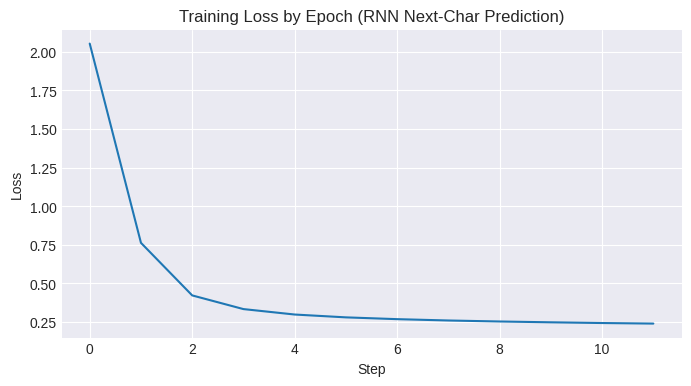

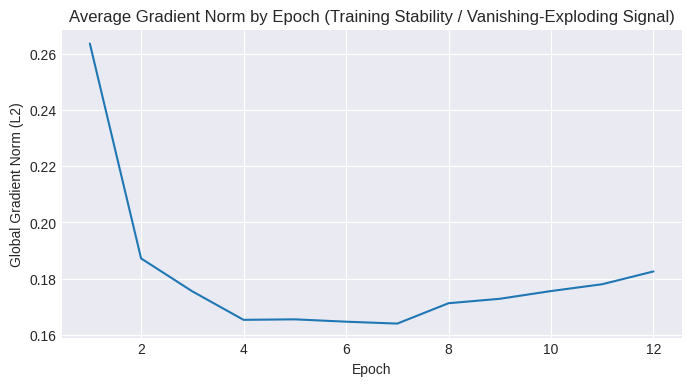

In [6]:
# ===============================
# CELL 6
# ===============================
# Evaluation metrics + plot loss curve
train_metrics = evaluate(model, X_train[:min(2000, X_train.shape[0])], y_train[:min(2000, y_train.shape[0])])
test_metrics = evaluate(model, X_test[:min(2000, X_test.shape[0])], y_test[:min(2000, y_test.shape[0])])

train_ppl = float(np.exp(train_metrics["loss"]))
test_ppl = float(np.exp(test_metrics["loss"]))

print("Train metrics:", train_metrics, "Perplexity:", train_ppl)
print("Test  metrics:", test_metrics, "Perplexity:", test_ppl)

plot_loss_curve(train_losses, title="Training Loss by Epoch (RNN Next-Char Prediction)")

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(train_grad_norms) + 1), train_grad_norms)
plt.xlabel("Epoch")
plt.ylabel("Global Gradient Norm (L2)")
plt.title("Average Gradient Norm by Epoch (Training Stability / Vanishing-Exploding Signal)")
plt.show()

##7.INFERENCE

###7.1.OVERVIEW

**Cell 7 — Inference Demonstration via Greedy Text Generation and Next-Character Prediction**

Cell 7 is the notebook’s explicit inference demonstration. This is where the difference between “predict next character given true history” and “generate a sequence by feeding back predictions” becomes concrete. The cell defines `generate_text_greedy`, which takes a seed prompt and iteratively generates new characters. At each step, it runs the model forward on the current context, takes the logits at the final time step, selects the argmax character (greedy decoding), appends it to the output, and then uses that predicted character as part of the next input context.

This procedure highlights a fundamental inference dynamic for sequence models: the model becomes part of the data-generation process. During training, the model always conditions on true characters. During generation, it conditions on its own outputs. Any mistake alters the context and can push the hidden state into regions the model did not see during training. This is why generated text can drift into repetitive loops or degrade in coherence even if the model’s token accuracy looks decent under teacher forcing.

The prompt used in this cell is a new synthetic phrase in the same style as the corpus but not simply copied as a contiguous training window. The generated continuation is printed, giving the student an immediate qualitative sense of what the model learned: punctuation patterns, spacing, common phrases, and the template-like structure.

The cell also visualizes the prompt as token IDs in a heatmap strip. This visualization is simple but meaningful: it reinforces that the model does not see letters; it sees integer indices. The embedding layer later turns those indices into vectors. Seeing the token strip makes that representational pipeline tangible.

Finally, the cell performs a direct next-character prediction for the prompt: it runs the model on the prompt and prints the predicted next character. This is the most “pure” inference version of the training task: given a context, output the next token. It ties back directly to the supervised dataset definition.

The mechanical takeaway from Cell 7 is that inference can mean two things in sequence modeling. One is scoring or predicting the next token given a context (aligned with training). The other is free-running generation, where the model’s outputs recursively become inputs. Understanding this distinction is crucial for interpreting sequence model behavior and for motivating why later models and training procedures try to reduce exposure bias and improve long-range coherence.

###7.2.CODE AND IMPLEMENTATION

=== Prompt ===
Meanwhile, Holmes observed a torn letter at Baker Street, with calm certainty.


=== Generated continuation (greedy) ===
Meanwhile, Holmes observed a torn letter at Baker Street, with calm certainty.

At the riverside, the clerk insisted a torn letter; as a result, we listened with careful emphasis. At the railway station, the landlady insisted a torn letter; as a result, we listened with careful emphasis. At the railway station, the landlady insisted a to


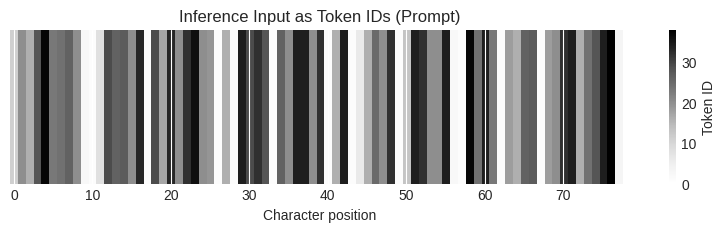

Predicted next character after prompt: '\n'


In [7]:
# ===============================
# CELL 7
# ===============================
# Inference demonstration: generate NEW synthetic sample and run prediction
def generate_text_greedy(
    model: nn.Module,
    seed_text: str,
    stoi: Dict[str, int],
    itos: Dict[int, str],
    gen_len: int = 200
) -> str:
    model.eval()
    # Ensure seed_text contains only known chars (fallback to space)
    safe = []
    for ch in seed_text:
        safe.append(ch if ch in stoi else " ")
    seed_text = "".join(safe)

    tokens = [stoi[ch] for ch in seed_text]
    x = torch.tensor(tokens, dtype=torch.long, device=DEVICE).unsqueeze(0)  # (1, T)

    out_chars = list(seed_text)
    for _ in range(gen_len):
        with torch.no_grad():
            logits = model(x)               # (1, T, V)
            next_logits = logits[:, -1, :]  # (1, V)
            next_id = int(torch.argmax(next_logits, dim=-1).item())
        out_chars.append(itos[next_id])
        # append token and keep context window
        tokens.append(next_id)
        tokens = tokens[-SEQ_LEN:]  # keep bounded context for computation
        x = torch.tensor(tokens, dtype=torch.long, device=DEVICE).unsqueeze(0)

    return "".join(out_chars)

# NEW synthetic prompt (not copied from training examples as a contiguous chunk)
new_prompt = "Meanwhile, Holmes observed a torn letter at Baker Street, with calm certainty.\n"
generated = generate_text_greedy(model, new_prompt, stoi, itos, gen_len=260)

print("=== Prompt ===")
print(new_prompt)
print("\n=== Generated continuation (greedy) ===")
print(generated)

# Visualize input as a simple token-index strip (structure of inference input)
prompt_ids = np.array([stoi.get(ch, stoi[" "]) for ch in new_prompt], dtype=np.int64)
plt.figure(figsize=(10, 2))
plt.imshow(prompt_ids[None, :], aspect="auto")
plt.yticks([])
plt.xlabel("Character position")
plt.title("Inference Input as Token IDs (Prompt)")
plt.colorbar(label="Token ID")
plt.show()

# Predict next character for the prompt
x_prompt = torch.tensor(prompt_ids[-min(len(prompt_ids), SEQ_LEN):], dtype=torch.long, device=DEVICE).unsqueeze(0)
with torch.no_grad():
    logits = model(x_prompt)
    next_id = int(torch.argmax(logits[:, -1, :], dim=-1).item())
print("Predicted next character after prompt:", repr(itos[next_id]))

##8.STRESS TEST

###8.1.OVERVIEW

**Cell 8 — Stress Test: Sequence Length Shift and Its Effect on Performance**

Cell 8 implements the chapter’s stress test by changing a single variable: the evaluation sequence length. The model was trained on windows of a fixed length (`SEQ_LEN=64`). In this cell, the notebook evaluates the same trained model on datasets constructed with sequence lengths 32, 64, and 128. This is not retraining; it is a test of robustness under a distribution shift in the temporal dimension.

Mechanically, changing sequence length changes the “unrolled depth” the model must handle in a single forward pass and the dependency range visible in the window. For evaluation loss, longer sequences mean more positions to predict, and potentially more opportunities for mistakes. If the model’s memory is fragile, performance may degrade as sequence length increases because the hidden state must carry useful information over longer spans and because earlier context might matter for later predictions. Conversely, shorter sequences can sometimes appear easier because dependencies are more local.

The evaluation function in this cell reconstructs the dataset at each sequence length using the same encoded corpus. It performs a deterministic train/test split and then evaluates the model on a bounded number of test sequences to keep runtime reasonable. It reports loss, accuracy, and perplexity. Importantly, perplexity is computed from the evaluated loss, so it reflects actual measured uncertainty.

The cell then visualizes perplexity and accuracy as a function of sequence length. This plot turns an abstract idea—“longer contexts are harder for vanilla RNNs”—into a measurable relationship. Students should interpret the trend, not just the absolute values. If perplexity rises with sequence length, it suggests the model is less confident and less correct on longer contexts. If accuracy falls, it suggests exact next-character prediction becomes harder as context length increases.

The mechanical takeaway from Cell 8 is that sequence models are sensitive to temporal scale. Even when the data distribution is otherwise unchanged, altering the length of sequences can change the effective difficulty because it changes how memory and state dynamics are used. This sensitivity is one of the main ceilings of vanilla RNNs and sets up the motivation for LSTMs: gating mechanisms that maintain and control memory over longer horizons.

###8.2.CODE AND IMPLEMENTATION

Stress test results:
Short  seq_len=32 : {'loss': 0.3050943613052368, 'accuracy': 0.890666663646698, 'perplexity': 1.356753021952147, 'seq_len': 32.0}
Base   seq_len=64 : {'loss': 0.24080249667167664, 'accuracy': 0.9108020663261414, 'perplexity': 1.2722697329857338, 'seq_len': 64.0}
Long   seq_len=128: {'loss': 0.20560069382190704, 'accuracy': 0.9218072891235352, 'perplexity': 1.2282626531961056, 'seq_len': 128.0}


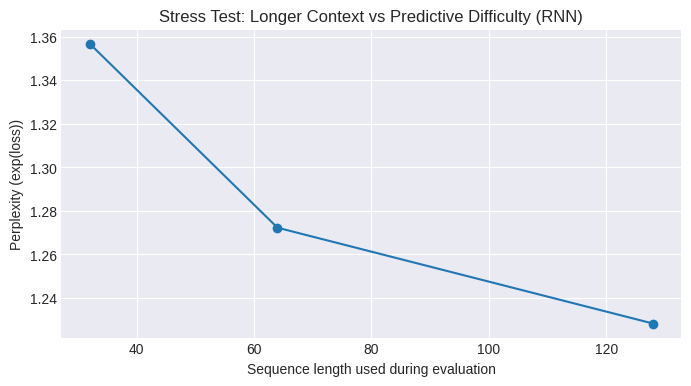

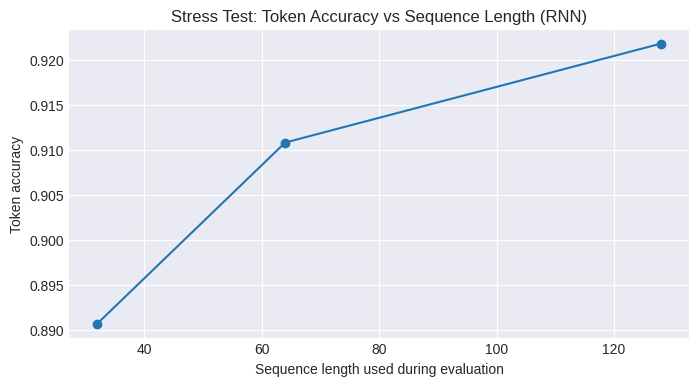

In [8]:
# ===============================
# CELL 8
# ===============================
# Stress test / ablation: longer sequences (harder credit assignment) vs baseline
def evaluate_with_seq_len(encoded: np.ndarray, seq_len: int, stride: int, seed: int = 0) -> Dict[str, float]:
    X_np_s, y_np_s = make_sequence_dataset(encoded, seq_len=seq_len, stride=stride)
    X_tr_np, y_tr_np, X_te_np, y_te_np = train_test_split_np(X_np_s, y_np_s, test_ratio=0.2, seed=seed)

    X_te = torch.from_numpy(X_te_np[:min(1500, X_te_np.shape[0])]).long().to(DEVICE)
    y_te = torch.from_numpy(y_te_np[:min(1500, y_te_np.shape[0])]).long().to(DEVICE)

    m = evaluate(model, X_te, y_te)
    m["perplexity"] = float(np.exp(m["loss"]))
    m["seq_len"] = float(seq_len)
    return m

baseline_eval = evaluate_with_seq_len(encoded, seq_len=SEQ_LEN, stride=STRIDE, seed=0)
long_eval = evaluate_with_seq_len(encoded, seq_len=128, stride=STRIDE, seed=0)
short_eval = evaluate_with_seq_len(encoded, seq_len=32, stride=STRIDE, seed=0)

print("Stress test results:")
print("Short  seq_len=32 :", short_eval)
print("Base   seq_len=64 :", baseline_eval)
print("Long   seq_len=128:", long_eval)

# Visualize degradation/improvement
seqs = np.array([32, 64, 128], dtype=np.int64)
ppls = np.array([short_eval["perplexity"], baseline_eval["perplexity"], long_eval["perplexity"]], dtype=np.float64)
accs = np.array([short_eval["accuracy"], baseline_eval["accuracy"], long_eval["accuracy"]], dtype=np.float64)

plt.figure(figsize=(8, 4))
plt.plot(seqs, ppls, marker="o")
plt.xlabel("Sequence length used during evaluation")
plt.ylabel("Perplexity (exp(loss))")
plt.title("Stress Test: Longer Context vs Predictive Difficulty (RNN)")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(seqs, accs, marker="o")
plt.xlabel("Sequence length used during evaluation")
plt.ylabel("Token accuracy")
plt.title("Stress Test: Token Accuracy vs Sequence Length (RNN)")
plt.show()

##9.INTERPRETATION

###9.1.0VERVIEW

**Cell 9 — Interpretability: Hidden-State Magnitude and Gradient Signal Over Time Steps**

Cell 9 provides the interpretability visualization required by the chapter spec. For RNNs, interpretability in this lab is not about semantic meaning. It is about dynamics: how the hidden state behaves across time, and how learning signal distributes across time when the model is asked to predict at every step.

The cell defines `timestep_grad_norms_on_batch`, which performs a careful computation on a representative batch. First, it runs the embedding layer to obtain a sequence of input vectors. Then, rather than relying on the standard RNN forward that returns an output sequence and final hidden state, it explicitly steps through time, calling the RNN on a length-1 slice at each time step. This produces a list of hidden states (one per time step), which are stacked into a tensor `h_stack` of shape `(B, T, H)`.

The key interpretability move is to treat `h_stack` as the object of interest and compute gradients of the loss with respect to it. The cell constructs logits from these hidden states using the output linear layer and computes cross-entropy loss. Then it uses `torch.autograd.grad` to compute `dL/dh_stack`. This yields a gradient tensor over time steps and hidden dimensions. By taking norms, the notebook reduces this to a single curve: the mean gradient magnitude at each time step. This is a direct visualization of where learning signal is strong or weak across the sequence.

Two plots are produced. The first shows the mean hidden-state norm `||h_t||` over time. This indicates whether hidden activations grow, decay, or remain stable across the window. The second shows the mean gradient norm `||dL/dh_t||` over time. If this gradient norm decays rapidly for earlier time steps, it illustrates the vanishing gradient phenomenon: the loss at later positions has weak sensitivity to earlier hidden states, making it hard for the model to learn long-range dependencies.

The cell also prints a decoded example sequence for context. This anchors the plots in something human-readable: the student can see the kind of text the model is processing while interpreting the state/gradient dynamics.

The mechanical takeaway from Cell 9 is that the vanishing/exploding gradient problem is not a slogan; it is a property of computed derivatives in the unrolled computation graph. By plotting gradient norms over time, the notebook turns an optimization limitation into an observable object. This is exactly the conceptual bridge needed for Chapter 5, where LSTMs introduce gates that create more stable pathways for information and gradients to persist over longer horizons.

###9.2.CODE AND IMPLEMENTATION

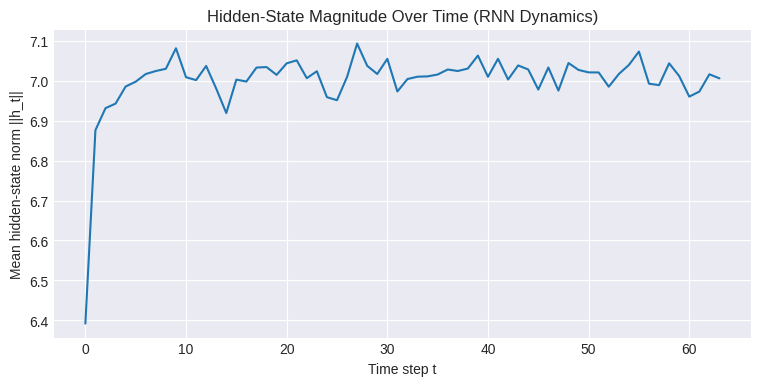

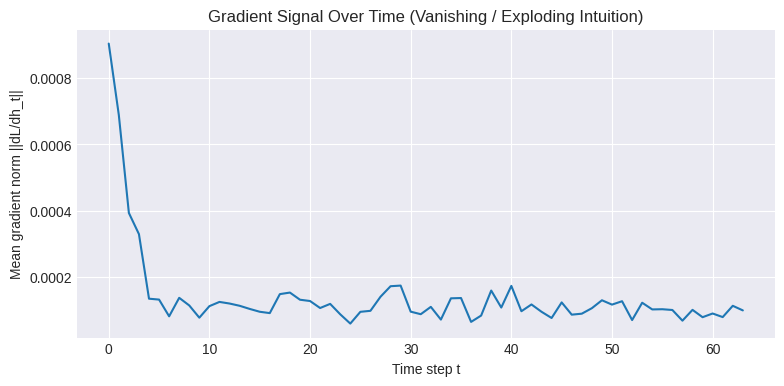

Decoded X (first 120 chars):
the visitor suspected a sealed envelope; nevertheless, we listen

Decoded y (first 120 chars):
he visitor suspected a sealed envelope; nevertheless, we listene


In [9]:
# ===============================
# CELL 9
# ===============================
# Interpretability visualization: hidden-state norms + gradient norms over time steps (vanishing/exploding intuition)
def timestep_grad_norms_on_batch(
    model: CharRNN,
    xb: torch.Tensor,
    yb: torch.Tensor,
    max_t: int = 64
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute:
    - hidden state norm over time (||h_t||)
    - gradient norm of loss w.r.t hidden states per time step (||dL/dh_t||)
    Uses a single batch for interpretability.
    """
    model.eval()
    xb = xb[:, :max_t]
    yb = yb[:, :max_t]

    # Forward manually to retain per-timestep hidden states
    emb = model.emb(xb)  # (B, T, E)
    B, T, E = emb.shape

    rnn = model.rnn
    H = rnn.hidden_size

    # Initial hidden state
    h_t = torch.zeros((rnn.num_layers, B, H), device=xb.device, dtype=emb.dtype)
    h_seq = []
    for t in range(T):
        # One-step RNN update using internal weights: use rnn on length-1 sequence for clarity
        out_t, h_t = rnn(emb[:, t:t+1, :], h_t)  # out_t: (B,1,H)
        h_seq.append(out_t[:, 0, :])            # (B,H)

    h_stack = torch.stack(h_seq, dim=1)         # (B,T,H)
    h_stack = h_stack.requires_grad_(True)      # treat as leaf for per-step gradient readout

    # Produce logits from these hidden states
    logits = model.fc(h_stack)                  # (B,T,V)
    loss = F.cross_entropy(logits.reshape(B * T, VOCAB_SIZE), yb.reshape(B * T))

    # Backprop to hidden states (not to parameters)
    grads = torch.autograd.grad(loss, h_stack, retain_graph=False, create_graph=False)[0]  # (B,T,H)

    # Norms
    h_norm = torch.sqrt(torch.sum(h_stack.detach() ** 2, dim=-1)).mean(dim=0)      # (T,)
    g_norm = torch.sqrt(torch.sum(grads.detach() ** 2, dim=-1)).mean(dim=0)        # (T,)

    return h_norm.cpu().numpy(), g_norm.cpu().numpy()

# Choose a representative batch from test set
B_INT = min(64, X_test.shape[0])
xb_int = X_test[:B_INT]
yb_int = y_test[:B_INT]

h_norm, g_norm = timestep_grad_norms_on_batch(model, xb_int, yb_int, max_t=SEQ_LEN)

t = np.arange(len(h_norm))
plt.figure(figsize=(9, 4))
plt.plot(t, h_norm)
plt.xlabel("Time step t")
plt.ylabel("Mean hidden-state norm ||h_t||")
plt.title("Hidden-State Magnitude Over Time (RNN Dynamics)")
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(t, g_norm)
plt.xlabel("Time step t")
plt.ylabel("Mean gradient norm ||dL/dh_t||")
plt.title("Gradient Signal Over Time (Vanishing / Exploding Intuition)")
plt.show()

# Show a decoded sequence for context
x_ex = X_test_np[0]
y_ex = y_test_np[0]
print("Decoded X (first 120 chars):")
print(decode_ints(x_ex[:120], itos))
print("\nDecoded y (first 120 chars):")
print(decode_ints(y_ex[:120], itos))

##10.AUDIT BUNDLE

###10.1.OVERVIEW

**Cell 10 — Artifact Saving and Summary Metrics Dictionary**

Cell 10 saves the notebook’s outputs as artifacts and prints a summary metrics dictionary. This cell has two purposes. First, it makes the run reproducible beyond the interactive notebook session by writing key results to disk. Second, it creates a structured set of metrics that Cell 11 can reference for reflective summarization without inventing numbers.

The cell creates a directory in `/content/` and saves multiple artifact types. It writes `summary_metrics.json`, which contains the central scalar results: vocabulary size, sequence length, stride, parameter count, final training loss, gradient norms, train/test evaluation loss and accuracy, and derived perplexities. It also stores stress test metrics for sequence lengths 32, 64, and 128. Finally, it stores interpretability summaries such as the mean hidden-state norm and mean hidden-gradient norm. These metrics are not arbitrary; they correspond directly to computations performed earlier. This is important for mechanical integrity: every number in the summary dictionary has a computational provenance.

The cell also saves arrays: training losses per epoch, gradient norms per epoch, hidden-state norms over time, and gradient norms over time. Saving arrays, not just scalars, preserves the shape of learning dynamics, enabling later analysis or plotting without rerunning training. The generated text sample is saved to a `.txt` file so the qualitative inference example is preserved as an output artifact. Finally, the model’s weights are saved as a state dict. This is pedagogically useful because it reinforces that “training” produces parameter values that can be reused independently of training code.

After saving, the cell prints the artifact directory and prints the summary metrics dictionary in JSON form. This printout serves a dual role: it is a human-readable run report and it is a debugging aid. If something looks off (e.g., unusually high perplexity or near-zero accuracy), you can detect it immediately.

The mechanical takeaway from Cell 10 is that experiments are defined by artifacts, not by narratives. In a mechanics-first lab, the student should be able to point to: (i) the model weights that embody what was learned, (ii) the curves that describe how learning proceeded, (iii) the metrics that quantify performance, and (iv) the inference sample that demonstrates behavior. Cell 10 packages all of those into a durable record.

###10.2.CODE AND IMPLEMENTATION

In [10]:
# ===============================
# CELL 10
# ===============================
# Save artifacts + print summary metrics dictionary
art_dir = "/content/chapter4_rnn_artifacts"
os.makedirs(art_dir, exist_ok=True)

summary_metrics = {
    "vocab_size": int(VOCAB_SIZE),
    "seq_len_train": int(SEQ_LEN),
    "stride": int(STRIDE),
    "n_params": int(n_params),
    "train_loss_final": float(train_losses[-1]),
    "train_grad_norm_final": float(train_grad_norms[-1]),
    "train_eval_loss": float(train_metrics["loss"]),
    "train_eval_accuracy": float(train_metrics["accuracy"]),
    "train_eval_perplexity": float(train_ppl),
    "test_eval_loss": float(test_metrics["loss"]),
    "test_eval_accuracy": float(test_metrics["accuracy"]),
    "test_eval_perplexity": float(test_ppl),
    "stress_short_seq32_perplexity": float(short_eval["perplexity"]),
    "stress_base_seq64_perplexity": float(baseline_eval["perplexity"]),
    "stress_long_seq128_perplexity": float(long_eval["perplexity"]),
    "stress_short_seq32_accuracy": float(short_eval["accuracy"]),
    "stress_base_seq64_accuracy": float(baseline_eval["accuracy"]),
    "stress_long_seq128_accuracy": float(long_eval["accuracy"]),
    "interpret_hidden_norm_mean": float(np.mean(h_norm)),
    "interpret_grad_norm_mean": float(np.mean(g_norm)),
}

# Save metrics + curves + sample text
with open(os.path.join(art_dir, "summary_metrics.json"), "w") as f:
    json.dump(summary_metrics, f, indent=2)

np.save(os.path.join(art_dir, "train_losses.npy"), np.array(train_losses, dtype=np.float32))
np.save(os.path.join(art_dir, "train_grad_norms.npy"), np.array(train_grad_norms, dtype=np.float32))
np.save(os.path.join(art_dir, "hidden_norms.npy"), np.array(h_norm, dtype=np.float32))
np.save(os.path.join(art_dir, "hidden_grad_norms.npy"), np.array(g_norm, dtype=np.float32))

with open(os.path.join(art_dir, "generated_sample.txt"), "w") as f:
    f.write(generated)

# Save model weights (small)
torch.save(model.state_dict(), os.path.join(art_dir, "char_rnn_state_dict.pt"))

print("Artifacts saved to:", art_dir)
print("\nSummary metrics dictionary:")
print(json.dumps(summary_metrics, indent=2))

Artifacts saved to: /content/chapter4_rnn_artifacts

Summary metrics dictionary:
{
  "vocab_size": 39,
  "seq_len_train": 64,
  "stride": 3,
  "n_params": 10055,
  "train_loss_final": 0.24015894585422107,
  "train_grad_norm_final": 0.18252600932382246,
  "train_eval_loss": 0.23653702437877655,
  "train_eval_accuracy": 0.9114921689033508,
  "train_eval_perplexity": 1.2668544592511939,
  "test_eval_loss": 0.2417064905166626,
  "test_eval_accuracy": 0.9103984236717224,
  "test_eval_perplexity": 1.27342037700271,
  "stress_short_seq32_perplexity": 1.356753021952147,
  "stress_base_seq64_perplexity": 1.2722697329857338,
  "stress_long_seq128_perplexity": 1.2282626531961056,
  "stress_short_seq32_accuracy": 0.890666663646698,
  "stress_base_seq64_accuracy": 0.9108020663261414,
  "stress_long_seq128_accuracy": 0.9218072891235352,
  "interpret_hidden_norm_mean": 7.001152515411377,
  "interpret_grad_norm_mean": 0.00013815540296491235
}


## 11.EXPLANATION

###11.1.OVERVIEW

**Cell 11 — GPT-4o-mini Reflective Summarization Anchored to Real Computed Metrics**

Cell 11 performs structured reflective summarization using `gpt-4o-mini`, but it is constrained to reference real computed metrics from earlier cells. Mechanically, this cell is not part of model training; it is a post-run analysis tool that reads the notebook’s outputs and produces a human-friendly explanation. The cell imports `OpenAI` and `userdata` from Colab, initializes the client with the API key stored in the notebook’s secrets, and sets the model name explicitly to `"gpt-4o-mini"`.

The prompt is constructed as a structured request with eight required sections: dataset design, model architecture, training dynamics, quantitative results, inference example, visualization insight, limitations, and conceptual takeaway. This structure forces the summary to cover the full experiment pipeline rather than drifting into generic commentary. The prompt includes the `summary_metrics` JSON created in Cell 10, and it explicitly instructs the model not to invent numbers. This is crucial: the reflection must remain grounded in the actual run.

The cell then calls the chat completion endpoint with a low temperature. Low temperature reduces variance and encourages the model to produce consistent, factual summaries. The system message specifies the desired tone: rigorous, mechanics-first, no hype. The response is printed cleanly so the student can read it immediately after execution.

The mechanical takeaway from Cell 11 is that interpretation can be automated as long as it is tethered to computed evidence. The notebook generates plots, metrics, and artifacts through deterministic code; the reflection cell is a narrative layer that helps consolidate learning, but it is not allowed to replace measurement. When used correctly, it acts like a structured lab report generator: it explains what happened, why it happened, and what the limitations imply for the next model family—without changing the underlying experimental facts.

###11.2.CODE AND IMPLEMENTATION

In [11]:
# ===============================
# CELL 11
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model_name = "gpt-4o-mini"

prompt = f"""
You are reviewing an executed ML & AI 101 notebook chapter on a small character-level RNN trained on synthetic Sherlock-like text.

Return a structured analysis with the following sections (use clear labels, no markdown headings):
1) Dataset design
2) Model architecture
3) Training dynamics
4) Quantitative results
5) Inference example
6) Visualization insight (hidden state norms + gradient norms over time)
7) Limitations
8) Conceptual takeaway

IMPORTANT:
- You must reference the real metrics below (do not invent numbers).
- Keep it mechanics-first: training vs inference, sequence modeling, vanishing gradients intuition.

Real metrics (JSON):
{json.dumps(summary_metrics, indent=2)}

Additional context:
- The model is a small CharRNN (Embedding -> tanh RNN -> Linear) trained for next-character prediction.
- Stress test compares evaluation at sequence lengths 32 vs 64 vs 128.
- Interpretability computed mean ||h_t|| and mean ||dL/dh_t|| over time steps on a representative test batch.
"""

resp = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": "You are a rigorous, mechanics-first ML tutor. Do not use hype or governance language."},
        {"role": "user", "content": prompt},
    ],
    temperature=0.2,
)

print(resp.choices[0].message.content.strip())

1) Dataset design:  
The dataset consists of synthetic text modeled after Sherlock Holmes narratives, which is appropriate for character-level modeling. The vocabulary size is 39, indicating a limited set of characters, likely including letters, punctuation, and whitespace. The training sequences are of length 64, with a stride of 3, allowing for overlapping sequences during training. This design helps the model learn contextual relationships between characters effectively.

2) Model architecture:  
The model is a simple character-level RNN consisting of an embedding layer, a tanh activation function for the RNN cell, and a linear output layer. The architecture is straightforward, which is suitable for the task of next-character prediction. The total number of parameters in the model is 10,055, indicating a relatively small model that can be trained efficiently on the dataset.

3) Training dynamics:  
The training process appears to have been effective, as indicated by the final traini

##12.CONCLUSION

*Conclusion and Road Ahead*

This Chapter 4 notebook establishes the simplest working mechanism for temporal memory in neural modeling: the recurrent hidden state. By training a small character-level RNN on a synthetic but structured corpus, the notebook turns “sequence learning” into a concrete supervised learning problem with explicit inputs, explicit targets, and an explicit loss. The student sees how the same architecture used for static classification problems must be modified when order matters: the model must produce an output at every time step, and it must carry forward an internal state that summarizes context. That state is not a metaphor. It is a vector computed deterministically at each time step, and it is the pathway through which learning signal flows backward during training.

Mechanically, the notebook makes three contributions that are easy to miss in a purely theoretical introduction to RNNs. First, it shows that sequence modeling is supervised learning with many labels per example. Each training window produces `SEQ_LEN` classification targets, one for each next-character prediction. This densifies the supervision signal, which is why even a small dataset can support training. At the same time, it also means the model is effectively trained on an unrolled graph of depth `SEQ_LEN`, which immediately introduces optimization issues that do not appear as strongly in shallow feedforward settings.

Second, the notebook concretely separates training and inference in a sequential context. Training uses teacher forcing: the model always conditions on true previous characters. Inference can mean the aligned task (predict the next token given a true context), but it can also mean free-running generation, where the model’s own outputs become its future inputs. That feedback loop creates a new failure mode: errors compound and drift accumulates. Seeing this in generated text is more instructive than reading about it, because it reveals how small local uncertainties become global degradation over time.

Third, the notebook makes the vanishing/exploding gradient problem observable. It does not merely warn that gradients can vanish; it computes gradient norms and plots them. It tracks global parameter gradient norms over epochs to diagnose stability. More importantly, it computes gradients with respect to hidden states at each time step and visualizes how learning signal distributes across the sequence. This grounds the abstract idea of “credit assignment” in a measurable object: the magnitude of `dL/dh_t` as a function of time. If those gradients shrink for early time steps, it becomes clear why learning long-range dependencies is difficult for a vanilla RNN. The limitation is not that the model cannot represent dependencies in principle; the limitation is that learning them through gradient descent becomes fragile as the path length grows.

The stress test reinforces the same message from a different angle. By evaluating the trained model on different sequence lengths, the notebook demonstrates that temporal scale matters. A model trained on fixed-length windows may exhibit performance changes when asked to operate on shorter or longer contexts. This is not a trivial artifact: it reflects the core property of recurrence, namely that the hidden state must remain informative and stable across time. When sequence length increases, the model must maintain useful information longer and gradients must propagate across more repeated transformations. When sequence length decreases, the task becomes more local and may appear easier. Observing how perplexity and accuracy shift across these regimes is a practical way to understand the “ceiling” of vanilla RNNs.

That ceiling should be stated plainly. A simple tanh RNN is a minimal memory mechanism, not a robust one. Its hidden state is overwritten every step by the same transformation, and without additional structure it has no explicit control over what to keep, what to discard, and what to expose to the output. As a result, it tends to prioritize short-range patterns: common character bigrams, punctuation rhythms, whitespace placement, and repeated template fragments. It can still learn longer patterns to some extent, especially in a synthetic corpus with repetitive structure, but learning becomes progressively harder as the dependency horizon grows. This shows up in gradient dynamics and in sensitivity to sequence length.

The notebook also has deliberate simplifications. It uses character-level modeling rather than word-level or subword-level modeling, which keeps the vocabulary small but makes the sequence length longer for the same semantic content. It uses greedy decoding rather than sampling, beam search, or temperature control, which makes generation deterministic but can produce repetitive outputs. It uses a single-layer RNN and modest hidden dimension, which keeps parameter counts interpretable but limits representational capacity. None of these are defects in this educational context; they are design decisions that prioritize transparency over performance.

The important conceptual milestone, however, is achieved: the student sees a neural model that processes time and learns a stateful representation. They see how training works as backpropagation through time, and they see why that training becomes difficult. This is the precise point at which ML & AI 101 transitions naturally to the next model family.

The road ahead, therefore, is explicit. Chapter 5 introduces LSTMs, which are designed to address the main weakness made visible here: unstable long-horizon memory and weak gradient flow across long sequences. LSTMs add gating mechanisms that create controlled pathways for information to persist and for gradients to propagate. Instead of overwriting the entire memory state at each step, an LSTM learns when to write, when to forget, and when to expose stored information. Mechanically, this changes both the forward dynamics (memory becomes a distinct state variable with additive updates) and the backward dynamics (gradients can flow through near-identity paths, reducing vanishing). In other words, LSTMs are not “better RNNs” by magic; they are RNNs with a structural modification that directly targets the failure modes observed in this chapter.

This is the bridge: Chapter 4 teaches what recurrence is and why it matters, and it makes the core training limitation observable in real derivatives. Chapter 5 will keep the same sequence prediction framing, the same training vs inference distinction, and the same emphasis on visualization, but it will change the state update mechanism so that memory becomes more stable and learnable across longer time horizons. That transition is not an arbitrary model upgrade; it is a mechanical response to the specific ceilings exposed by the vanilla RNN in this lab.